# 3.6 softmax回归简约实现

通过深度学习框架的高级 API，我们可以极大简化实现过程。

流程：
- 初始化模型（引入 `nn.Flatten` 和 `nn.Sequential`）
- 解决数值稳定性问题（合二为一的损失函数）
- 定义优化器与训练

In [17]:
import torch
from IPython import display
from torch import nn
from d2l import torch as d2l
%run ../my_utils.py

## 1. 读取数据集

依然使用 Fashion-MNIST 数据集。

In [18]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

## 2. 初始化模型参数

为什么要做：
- 手写实现时需要手动 `reshape` 图像和初始化矩阵。
- `nn.Flatten()`：将图像从 `(batch, 1, 28, 28)` 展平为 `(batch, 784)`，将除了第零个维度外的所有维度展平。
- `nn.Sequential()`：按顺序将各层组合在一起。
- `nn.Linear(784, 10)`：定义全连接输出层，即输入 784 个特征，输出 10 个类别的分数。

张量形状变化：
- 输入: (batch, 1, 28, 28)
- Flatten 后: (batch, 784)
- Linear 后: (batch, 10)

In [19]:
# 定义网络结构
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

# 初始化权重
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

## 3. 定义损失函数（数值稳定性）

为什么要做：
- 在 3.5 节中，我们先算 `softmax` 再算 `log`。
- 问题：如果输出值太大，`exp(o)` 会**上溢**（变成 inf）；如果太小，`log` 会**下溢**。
- 解决：PyTorch 的 `nn.CrossEntropyLoss` 把 `softmax` 和 `log` 合在一起算了。它利用数学技巧（减去最大值）保证了计算过程不会爆炸。

注意：
- 此时模型的 `net(X)` 输出的是**未经过 softmax 的原始分数**（Logits）。
- 损失函数内部会自动帮你做 softmax。

In [20]:
loss = nn.CrossEntropyLoss(reduction='none')

## 4. 定义优化算法

使用学习率为 0.1 的小批量随机梯度下降（SGD）。  
- .parameters()：返回模型中所有可学习参数(w，b)的迭代器。

In [21]:
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

## 5. 训练

调用 `d2l` 的通用训练函数。

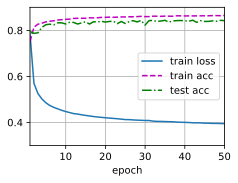

In [22]:
num_epochs = 50
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

一次训练时发现用了8分钟都没有结束，风扇噪音明显增大，重启vscode之后训练时间正常，原因不明，可能是之前的训练进程没有正常结束，导致资源占用过高。重启后清理了资源，训练时间恢复正常。

或者***见鬼了***。